In [37]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
import pandas as pd
from DFTStructureGenerator.Build_DataBase import (
    B_TYPE_ORDER,
    CL_SUBSTRATE_TYPE_ORDER,
    LB_TYPE_ORDER,
    get_boron_type,
    get_cl_substrate_type,
    get_lb_type,
)
from DFTStructureGenerator.project_paths import CSV_DIR, DESCRIPTOR_DIR, FIGURE_DIR, TS_DATA_DIR, repo_path
from DFTStructureGenerator.thermochemistry import apply_qharm_component_energies, database_path, load_reaction_dataset


## Reviewer Run Tags

- `[REVIEWER-RUNNABLE]`: can be run from files included in this repository, such as CSV, descriptor pickle, ASE database, Parquet, or existing figure inputs. No raw Gaussian working directory is required.
- `[RAW-GAUSSIAN/E:/work]`: depends on raw calculation artifacts, Gaussian logs, Mol files, ORCA/Gaussian input-output folders, or the external raw calculation root configured by `BORYLXAT_RAW_CALC_ROOT` (default `E:/work/B_Cl_Nu`). These cells document provenance but are not required for routine review reruns.
- `[OPTIONAL-DESCRIPTOR-GENERATION]`: regenerates descriptors from the released database. Reviewers can skip it and use the pre-extracted descriptor pickle files to save time.


In [38]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

np.random.seed(0)


In [40]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [41]:
duplicate_Cl_id = DUPLICATE_CL_IDS


In [49]:
# Thermochemistry switch: QHARM is the revised default; set False to reproduce the original RRHO analysis.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM)
BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"
BN_CSV_PATH = CSV_DIR / "reactants_B_N.csv"
CL_CSV_PATH = CSV_DIR / "reactants_Cl.csv"

# Descriptor source switch. Use "DFT" for the original descriptors or "xTB" for the cheaper xTB variant.
DESCRIPTOR_VARIANT = "xTB"

DFT_BN_RRHO_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2.pkl"
DFT_CL_RRHO_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2.pkl"
DFT_BN_QHARM_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2_qharm.pkl"
DFT_CL_QHARM_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2_qharm.pkl"
_qharm_dft_cache_exists = DFT_BN_QHARM_DESCRIPTOR_PATH.exists() and DFT_CL_QHARM_DESCRIPTOR_PATH.exists()
DFT_BN_DESCRIPTOR_PATH = DFT_BN_QHARM_DESCRIPTOR_PATH if USE_QHARM and _qharm_dft_cache_exists else DFT_BN_RRHO_DESCRIPTOR_PATH
DFT_CL_DESCRIPTOR_PATH = DFT_CL_QHARM_DESCRIPTOR_PATH if USE_QHARM and _qharm_dft_cache_exists else DFT_CL_RRHO_DESCRIPTOR_PATH
DFT_BN_REGENERATED_PATH = DFT_BN_QHARM_DESCRIPTOR_PATH if USE_QHARM else DFT_BN_RRHO_DESCRIPTOR_PATH
DFT_CL_REGENERATED_PATH = DFT_CL_QHARM_DESCRIPTOR_PATH if USE_QHARM else DFT_CL_RRHO_DESCRIPTOR_PATH
XTB_BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_xtb.pkl"
XTB_CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_xtb.pkl"

_DESCRIPTOR_PATHS = {
    "DFT": (DFT_BN_DESCRIPTOR_PATH, DFT_CL_DESCRIPTOR_PATH),
    "xTB": (XTB_BN_DESCRIPTOR_PATH, XTB_CL_DESCRIPTOR_PATH),
}
if DESCRIPTOR_VARIANT not in _DESCRIPTOR_PATHS:
    raise ValueError(f"DESCRIPTOR_VARIANT must be one of {list(_DESCRIPTOR_PATHS)}, got {DESCRIPTOR_VARIANT!r}")

BN_DESCRIPTOR_PATH, CL_DESCRIPTOR_PATH = _DESCRIPTOR_PATHS[DESCRIPTOR_VARIANT]

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using {DESCRIPTOR_VARIANT} descriptors")
print("Thermochemistry:", "QHARM" if USE_QHARM else "original RRHO")
print("Target column:", BARRIER_COLUMN)
print("Reaction-energy column:", REACTION_ENERGY_COLUMN)
print("Database:", DB_PATH)
print("BN descriptor path:", BN_DESCRIPTOR_PATH)
print("Cl descriptor path:", CL_DESCRIPTOR_PATH)


Using xTB descriptors
Thermochemistry: QHARM
Target column: deltaGa_qharm(kcal/mol)
Reaction-energy column: deltaG_qharm(kcal/mol)
Database: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\BorylXAT-DB_qh_update.db
BN descriptor path: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\BNdes_xtb.pkl
Cl descriptor path: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\Cldes_xtb.pkl


# Descriptor Generation [OPTIONAL-DESCRIPTOR-GENERATION]

Optional provenance/regeneration step. It rebuilds the DFT descriptor pickle files from the selected thermochemistry database. With `USE_QHARM=True`, descriptor entry zero is built from `gibbs_qharm_hartree` and saved to separate `*_qharm.pkl` files. Reviewers can skip these cells and start from **Feature Loading**.

This section writes `BNdes_new2_qharm.pkl`/`Cldes_new2_qharm.pkl` in QHARM mode and the historical `BNdes_new2.pkl`/`Cldes_new2.pkl` in RRHO mode. The xTB descriptor files are generated separately by `revision_xtb_export_descriptor_structures.ipynb`.


In [ ]:
B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
    use_qharm=USE_QHARM,
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=DFT_BN_REGENERATED_PATH,
    cl_path=DFT_CL_REGENERATED_PATH,
)
print("Saved regenerated DFT descriptors:")
print(" ", DFT_BN_REGENERATED_PATH)
print(" ", DFT_CL_REGENERATED_PATH)


# Feature Loading [REVIEWER-RUNNABLE]

Loads the descriptor pickle files selected by `DESCRIPTOR_VARIANT`:

- `"DFT"`: original DFT descriptors, `Data/descriptor/BNdes_new2.pkl` and `Data/descriptor/Cldes_new2.pkl`
- `"xTB"`: cheaper xTB descriptors, `Data/descriptor/BNdes_xtb.pkl` and `Data/descriptor/Cldes_xtb.pkl`

For xTB, generate the pickle files first with `revision_xtb_export_descriptor_structures.ipynb`.


In [50]:
missing_descriptor_paths = [
    path for path in [BN_DESCRIPTOR_PATH, CL_DESCRIPTOR_PATH]
    if not path.exists()
]
if missing_descriptor_paths:
    missing_text = "\n".join(str(path) for path in missing_descriptor_paths)
    raise FileNotFoundError(
        f"Missing {DESCRIPTOR_VARIANT} descriptor pickle file(s):\n{missing_text}\n"
        "For xTB descriptors, run revision_xtb_export_descriptor_structures.ipynb after xTB jobs finish."
    )

B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)
B_N_des_map, Cl_des_map = apply_qharm_component_energies(
    B_N_des_map, Cl_des_map, use_qharm=USE_QHARM, db_path=DB_PATH
)

bn_descriptor_length = len(next(iter(B_N_des_map.values()))) if B_N_des_map else 0
cl_descriptor_length = len(next(iter(Cl_des_map.values()))) if Cl_des_map else 0
print(f"Loaded {DESCRIPTOR_VARIANT} descriptors")
print(f"BN entries: {len(B_N_des_map)}; descriptor length: {bn_descriptor_length}")
print(f"Cl entries: {len(Cl_des_map)}; descriptor length: {cl_descriptor_length}")


Loaded xTB descriptors
BN entries: 4363; descriptor length: 10
Cl entries: 178; descriptor length: 9


# Training Model [REVIEWER-RUNNABLE]

Builds the CatBoost feature matrix from released descriptors and the released reaction CSV.


In [53]:
# Combined quantitative features used by the CatBoost barrier model.
data_csv = load_reaction_dataset(
    TS_DATA_DIR / "Borane_all.csv", use_qharm=USE_QHARM, db_path=DB_PATH
)
y = data_csv[BARRIER_COLUMN].to_numpy()
all_X = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
    reaction_energy_column=REACTION_ENERGY_COLUMN,
)
print(f"Feature matrix built from {DESCRIPTOR_VARIANT} descriptors: {all_X.shape}")


100%|██████████| 8980/8980 [00:00<00:00, 33530.06it/s]

Feature matrix built from xTB descriptors: (8980, 18)


In [54]:
all_X.shape


(8980, 18)

# Descriptor Correlation [REVIEWER-RUNNABLE]

Uses the loaded descriptors and target values only.


Max correlation:  0.9032403194115979


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.717847,0.361853,0.135238,0.288533,0.321980,0.103765,0.115564,0.120658,0.377106,0.024829,0.016012,0.088943,0.085178,0.082647,0.144844,0.255664,0.077485,0.020919
1,0.361853,0.309478,0.631602,0.612286,0.481359,0.230110,0.022496,0.031903,0.681010,0.036049,0.240990,0.168052,0.013605,0.281022,0.100368,0.241246,0.244581,0.234680
2,0.135238,0.631602,0.168555,0.306320,0.261328,0.849649,0.103283,0.002239,0.410935,0.093388,0.128655,0.100327,0.021071,0.148374,0.087433,0.155669,0.112803,0.109783
3,0.288533,0.612286,0.306320,0.232848,0.251306,0.000543,0.253846,0.028573,0.469596,0.217636,0.219441,0.135266,0.023928,0.210814,0.037903,0.132133,0.214046,0.214287
4,0.321980,0.481359,0.261328,0.251306,0.258949,0.131104,0.657387,0.111197,0.833967,0.135962,0.272774,0.197560,0.061570,0.364826,0.150430,0.308258,0.303716,0.302032
5,0.103765,0.230110,0.849649,0.000543,0.131104,0.003615,0.018350,0.067615,0.027891,0.088609,0.033012,0.005777,0.039244,0.040773,0.033449,0.009774,0.055120,0.058550
6,0.115564,0.022496,0.103283,0.253846,0.657387,0.018350,0.102195,0.203426,0.415861,0.093232,0.118359,0.099289,0.039469,0.187198,0.128986,0.189741,0.142331,0.137264
7,0.120658,0.031903,0.002239,0.028573,0.111197,0.067615,0.203426,0.058563,0.062137,0.108543,0.001958,0.006225,0.025066,0.008961,0.004360,0.000981,0.006819,0.007257
8,0.377106,0.681010,0.410935,0.469596,0.833967,0.027891,0.415861,0.062137,0.292904,0.089001,0.313294,0.203099,0.024375,0.371963,0.139179,0.302011,0.316050,0.329592
9,0.024829,0.036049,0.093388,0.217636,0.135962,0.088609,0.093232,0.108543,0.089001,0.078334,0.021680,0.020328,0.014177,0.010486,0.053891,0.031068,0.012856,0.006492


  0%|          | 0/181 [16:53<?, ?it/s]


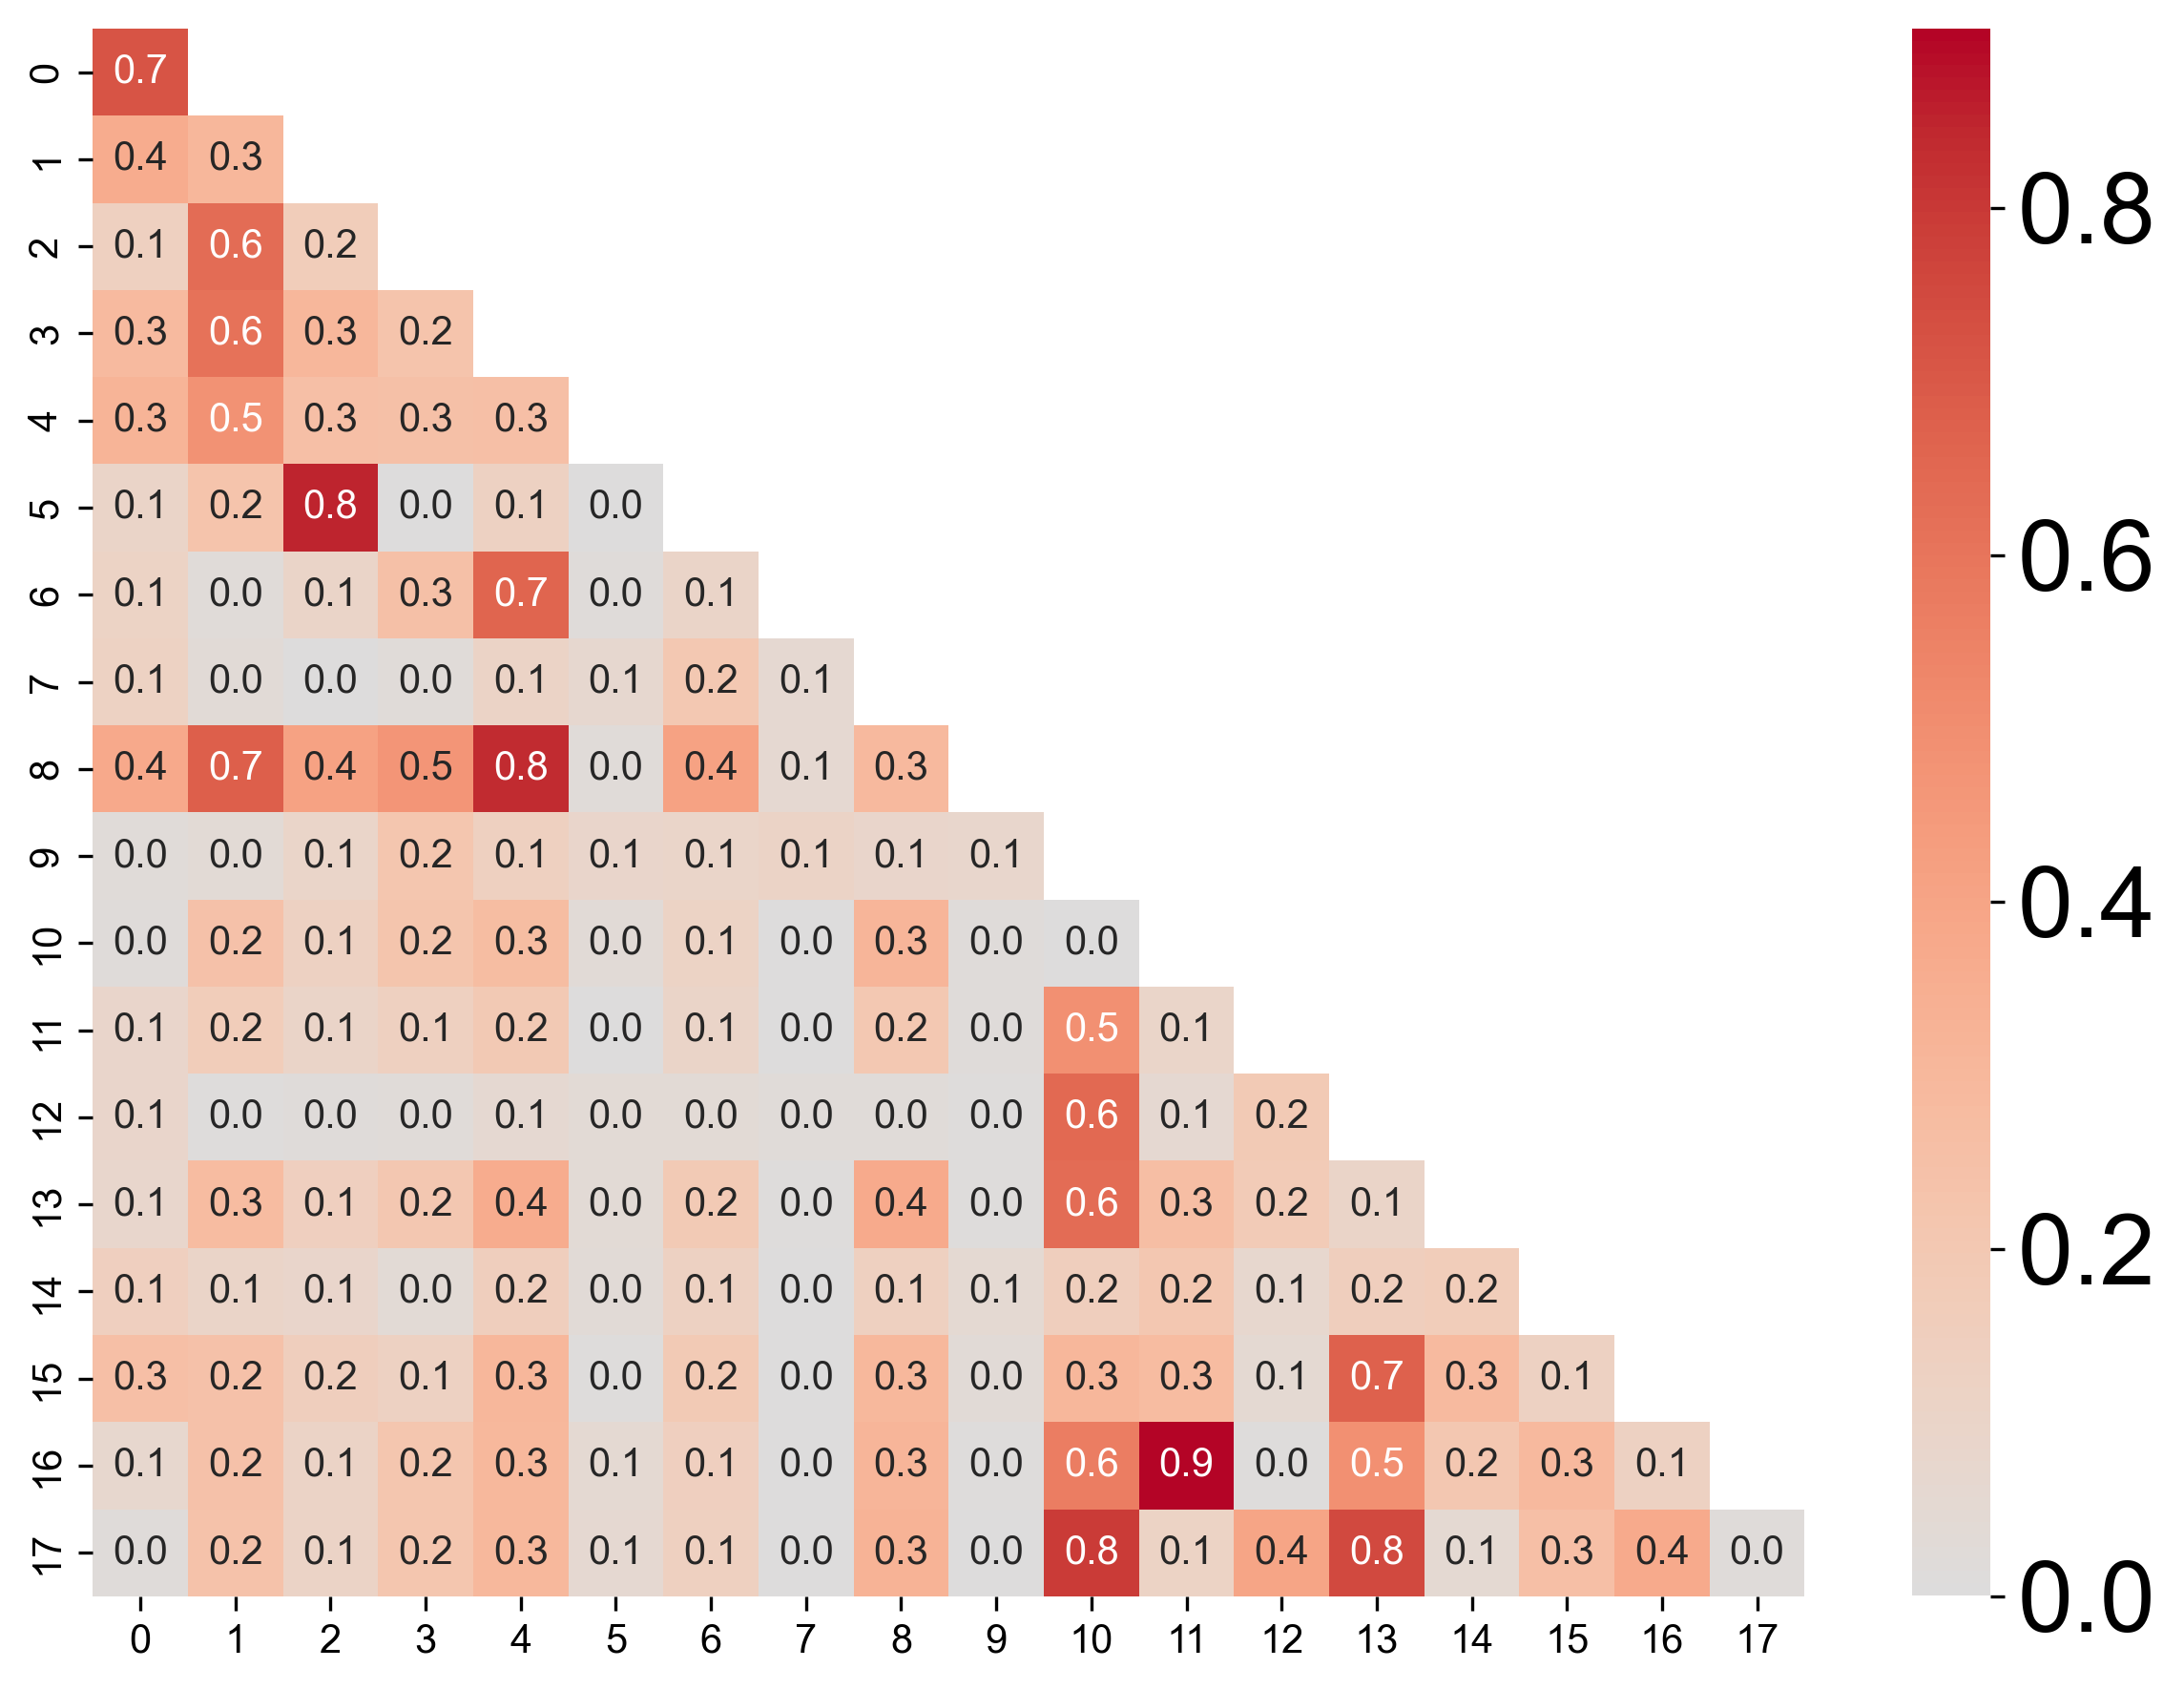

In [55]:
# Figure S21
descriptor_correlation_matrix = draw_correlation_map(
    all_X,
    figure_size=(8, 6),
    colors="coolwarm",
    annot=True,
    show_label=True,
    target=y,
)
plt.savefig(FIGURE_DIR / "FigureS21_descriptor_correlation_map_xtb.png", dpi=300, bbox_inches="tight")
descriptor_correlation_matrix


# 5-Fold Validation [REVIEWER-RUNNABLE]

Runs the reported random five-fold CatBoost validation from released descriptors.


In [56]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = np.zeros_like(y, dtype=float)

for train_ids, test_ids in kf.split(all_X):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=0,
    )
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])

    fold_r2 = r2_score(y[test_ids], y_pred)
    fold_mae = mean_absolute_error(y[test_ids], y_pred)
    fold_mse = mean_squared_error(y[test_ids], y_pred)
    print(f"R2: {fold_r2:.3f}, MAE: {fold_mae:.3f}, MSE: {fold_mse:.3f}")

    all_r2s.append(fold_r2)
    all_pred[test_ids] = y_pred

print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")


R2: 0.853, MAE: 1.353, MSE: 3.545
R2: 0.848, MAE: 1.409, MSE: 3.922
R2: 0.871, MAE: 1.298, MSE: 3.213
R2: 0.868, MAE: 1.312, MSE: 3.349
R2: 0.861, MAE: 1.367, MSE: 3.609
Mean of 5-Fold R2: 0.860


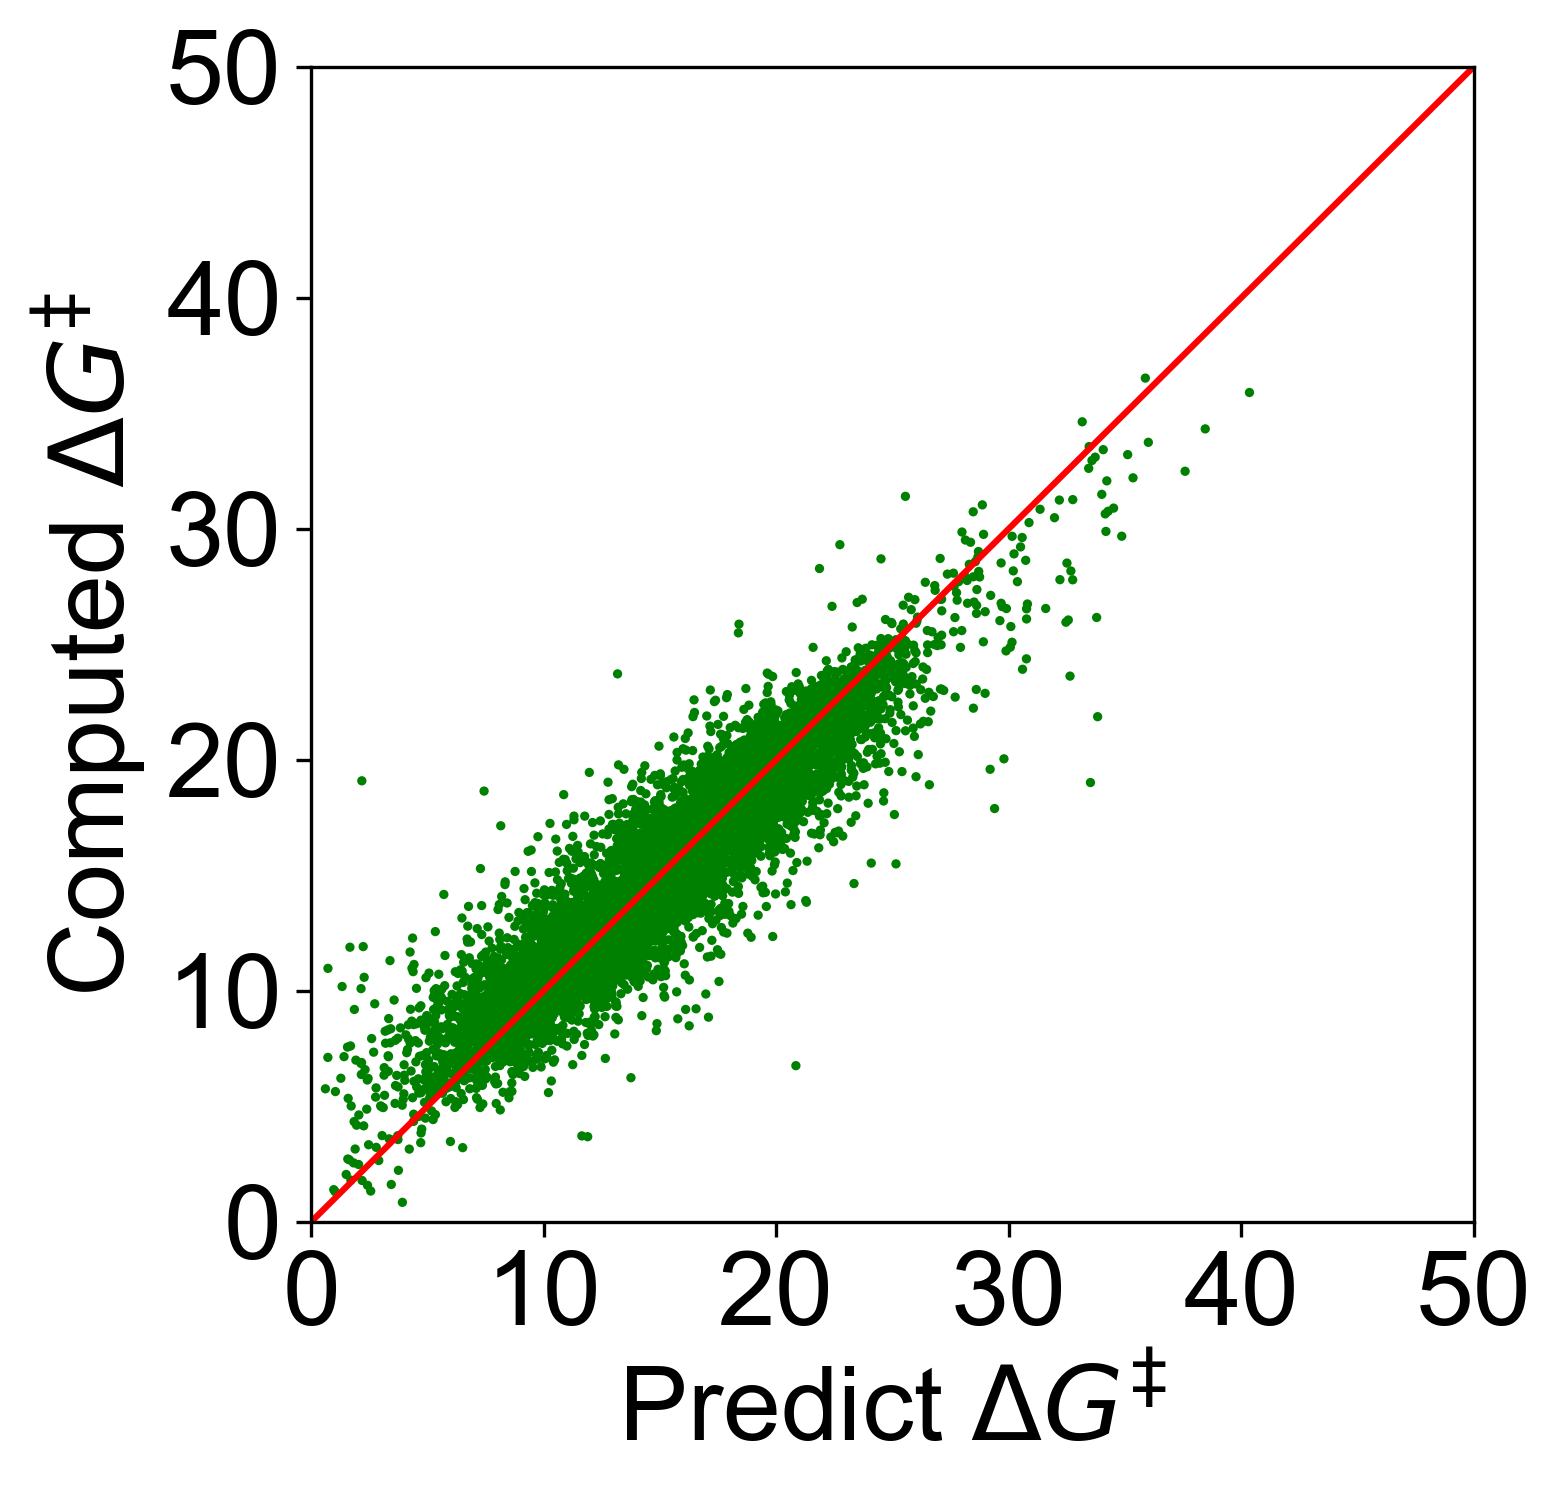

In [57]:
# Figure 6B
plot_scatter_with_metrics(
    y,
    all_pred,
    min_=0,
    max_=50,
    show=False,
)
# plt.savefig(FIGURE_DIR / "Figure6B_model_validation_xtb.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
    random_state=0,
)
model.fit(all_X, y)
feature_importances = model.feature_importances_


In [ ]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

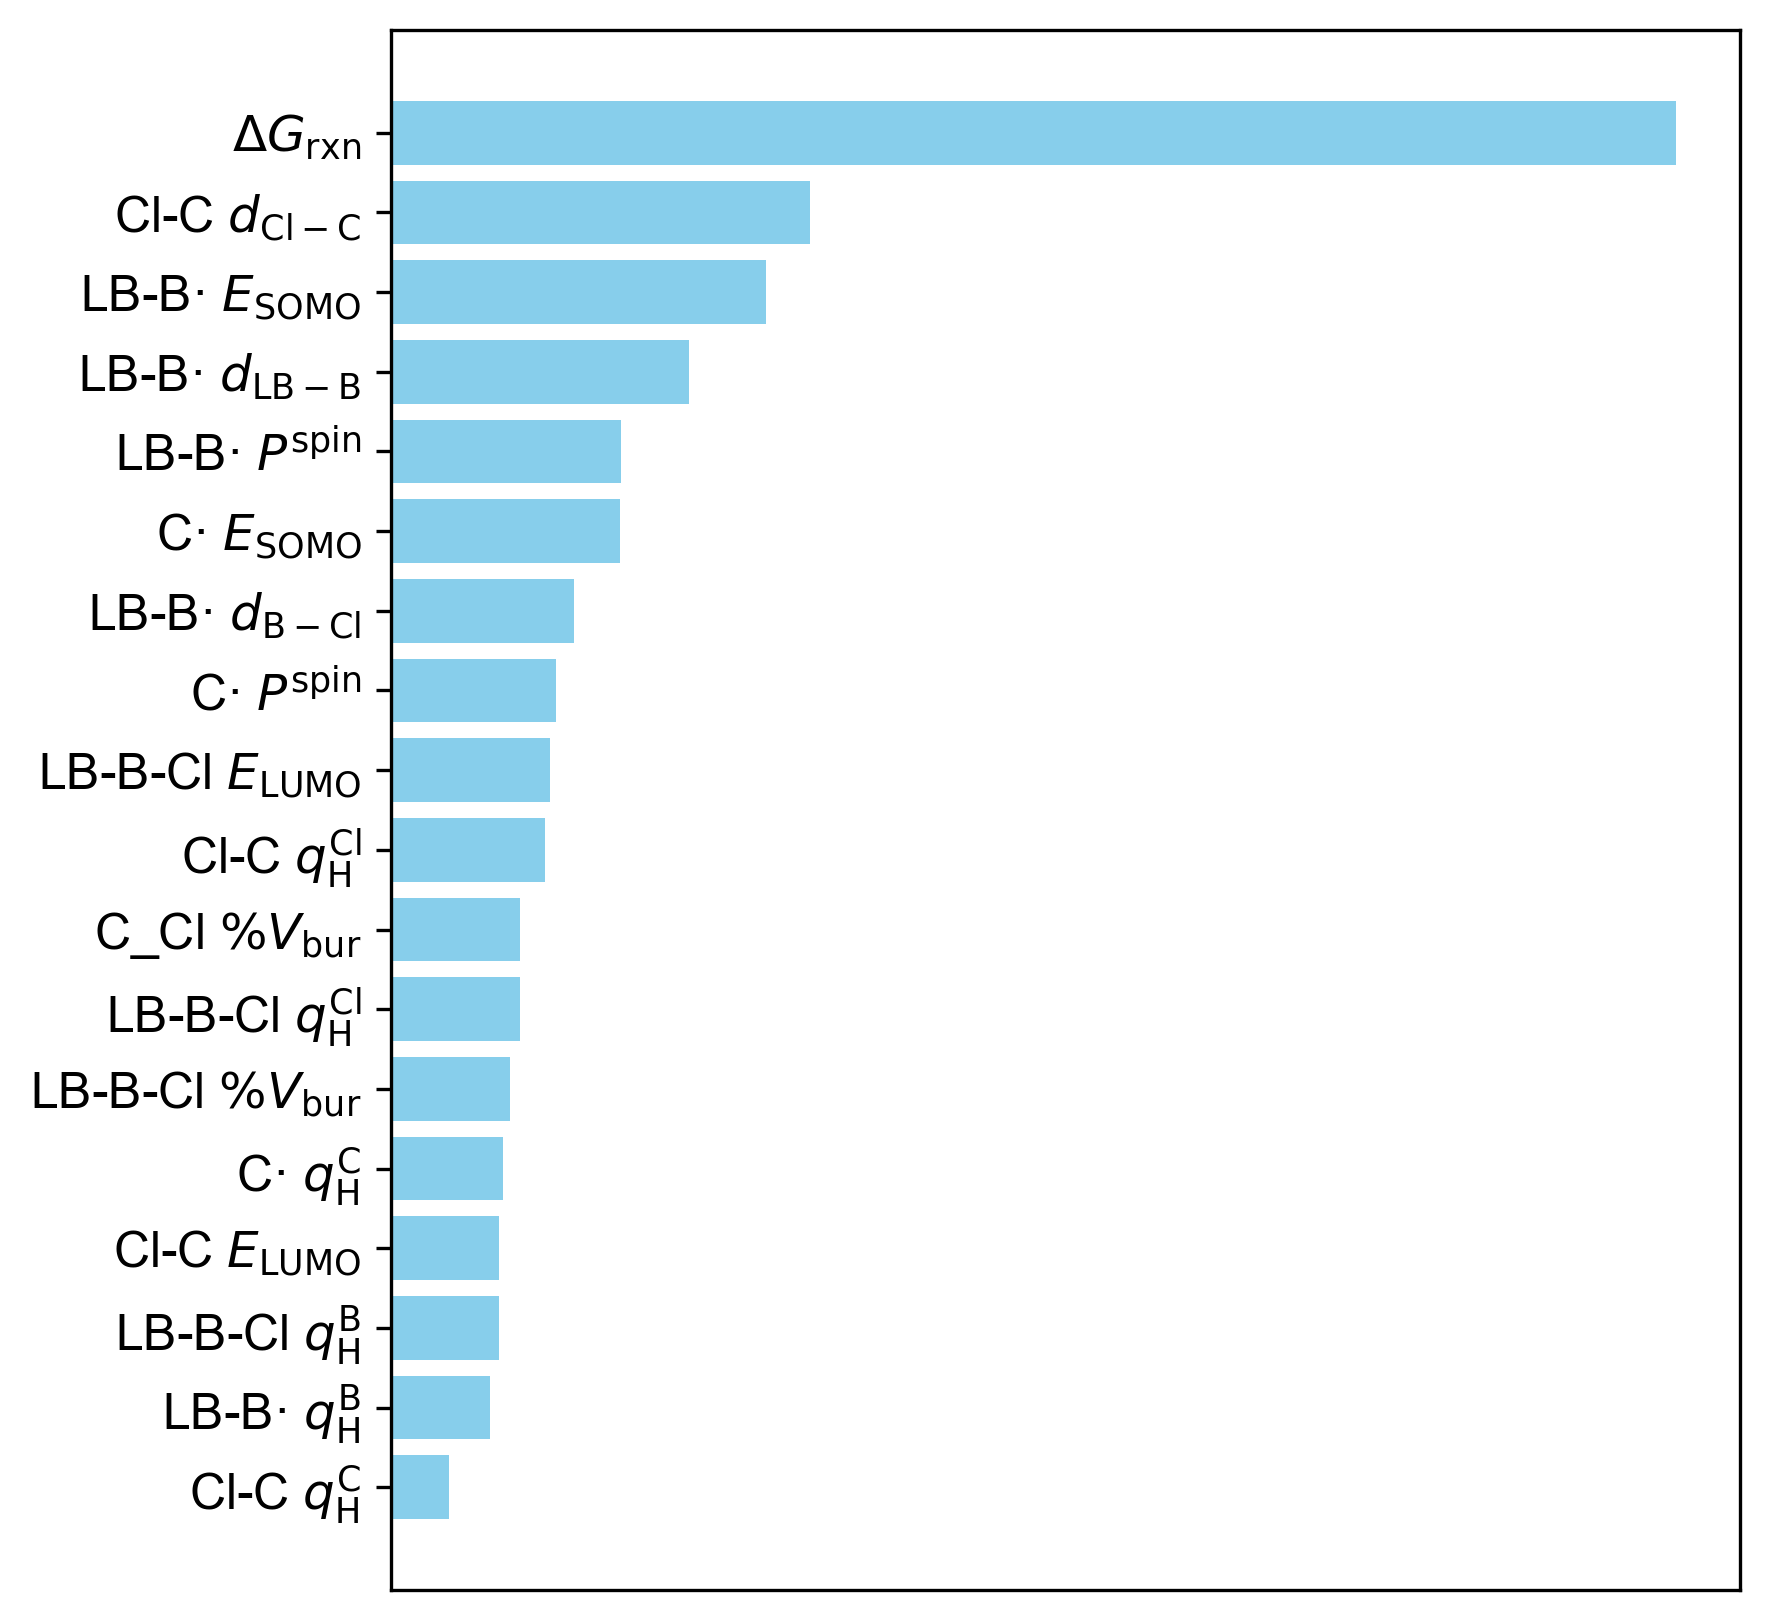

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)
plt.rcParams["font.sans-serif"] = "Arial"
feature_order = np.argsort(feature_importances)
ax.barh(
    np.array(des_name_std_sorted)[feature_order],
    feature_importances[feature_order],
    color="skyblue",
)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=12)
fig.tight_layout()
# fig.savefig(FIGURE_DIR / "Figure6C_model_feature_importance_xtb.png", dpi=300, bbox_inches="tight")
plt.show()


# Other Seeds [REVIEWER-RUNNABLE]

Optional robustness check using different random seeds; it is reviewer-runnable but more time-consuming than the main validation.


In [ ]:
y = data_csv[BARRIER_COLUMN].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for seed in range(10):
    all_r2s, all_mae, all_mse = [], [], []
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for train_ids, test_ids in list(kf.split(all_X)):
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state=0)
        # model = RandomForestRegressor()
        model.fit(all_X[train_ids], y[train_ids])
        y_pred = model.predict(all_X[test_ids])
        all_r2s.append(r2_score(y[test_ids], y_pred))
        all_mae.append(mean_absolute_error(y[test_ids], y_pred))
        all_mse.append(mean_squared_error(y[test_ids], y_pred))
    print(f"Seed: {seed}, R2: {np.mean(all_r2s):.3f}, MAE: {np.mean(all_mae):.3f}, MSE: {np.mean(all_mse):.3f}")

Seed: 0, R2: 0.860, MAE: 1.348, MSE: 3.528
Seed: 1, R2: 0.856, MAE: 1.358, MSE: 3.636
Seed: 2, R2: 0.857, MAE: 1.349, MSE: 3.600
Seed: 3, R2: 0.857, MAE: 1.352, MSE: 3.624
Seed: 4, R2: 0.860, MAE: 1.349, MSE: 3.547
Seed: 5, R2: 0.861, MAE: 1.338, MSE: 3.504
Seed: 6, R2: 0.858, MAE: 1.352, MSE: 3.593
Seed: 7, R2: 0.856, MAE: 1.357, MSE: 3.625
Seed: 8, R2: 0.857, MAE: 1.359, MSE: 3.609
Seed: 9, R2: 0.860, MAE: 1.346, MSE: 3.538


# OOD [REVIEWER-RUNNABLE]

Optional out-of-distribution validation from released descriptors and reaction metadata.


## OOD around Indexes [REVIEWER-RUNNABLE]

Component-index held-out validation; no raw Gaussian folders are required.


  0%|          | 0/181 [45:19:29<?, ?it/s]


OOD by Cl_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7058,1922,0.601151,2.385994,12.848330
1,Cl_Index,2,142,36,7296,1684,0.854915,1.398524,3.536901
2,Cl_Index,3,142,36,7348,1632,0.833984,1.449962,3.778592
3,Cl_Index,4,143,35,7200,1780,0.646649,2.072066,7.817774
4,Cl_Index,5,143,35,7018,1962,0.772813,1.585011,5.255390


Mean fold R2: 0.7419024378835735 MAE: 1.7783113568376538
Overall R2: 0.7312578888705685 MAE: 1.793474554864305


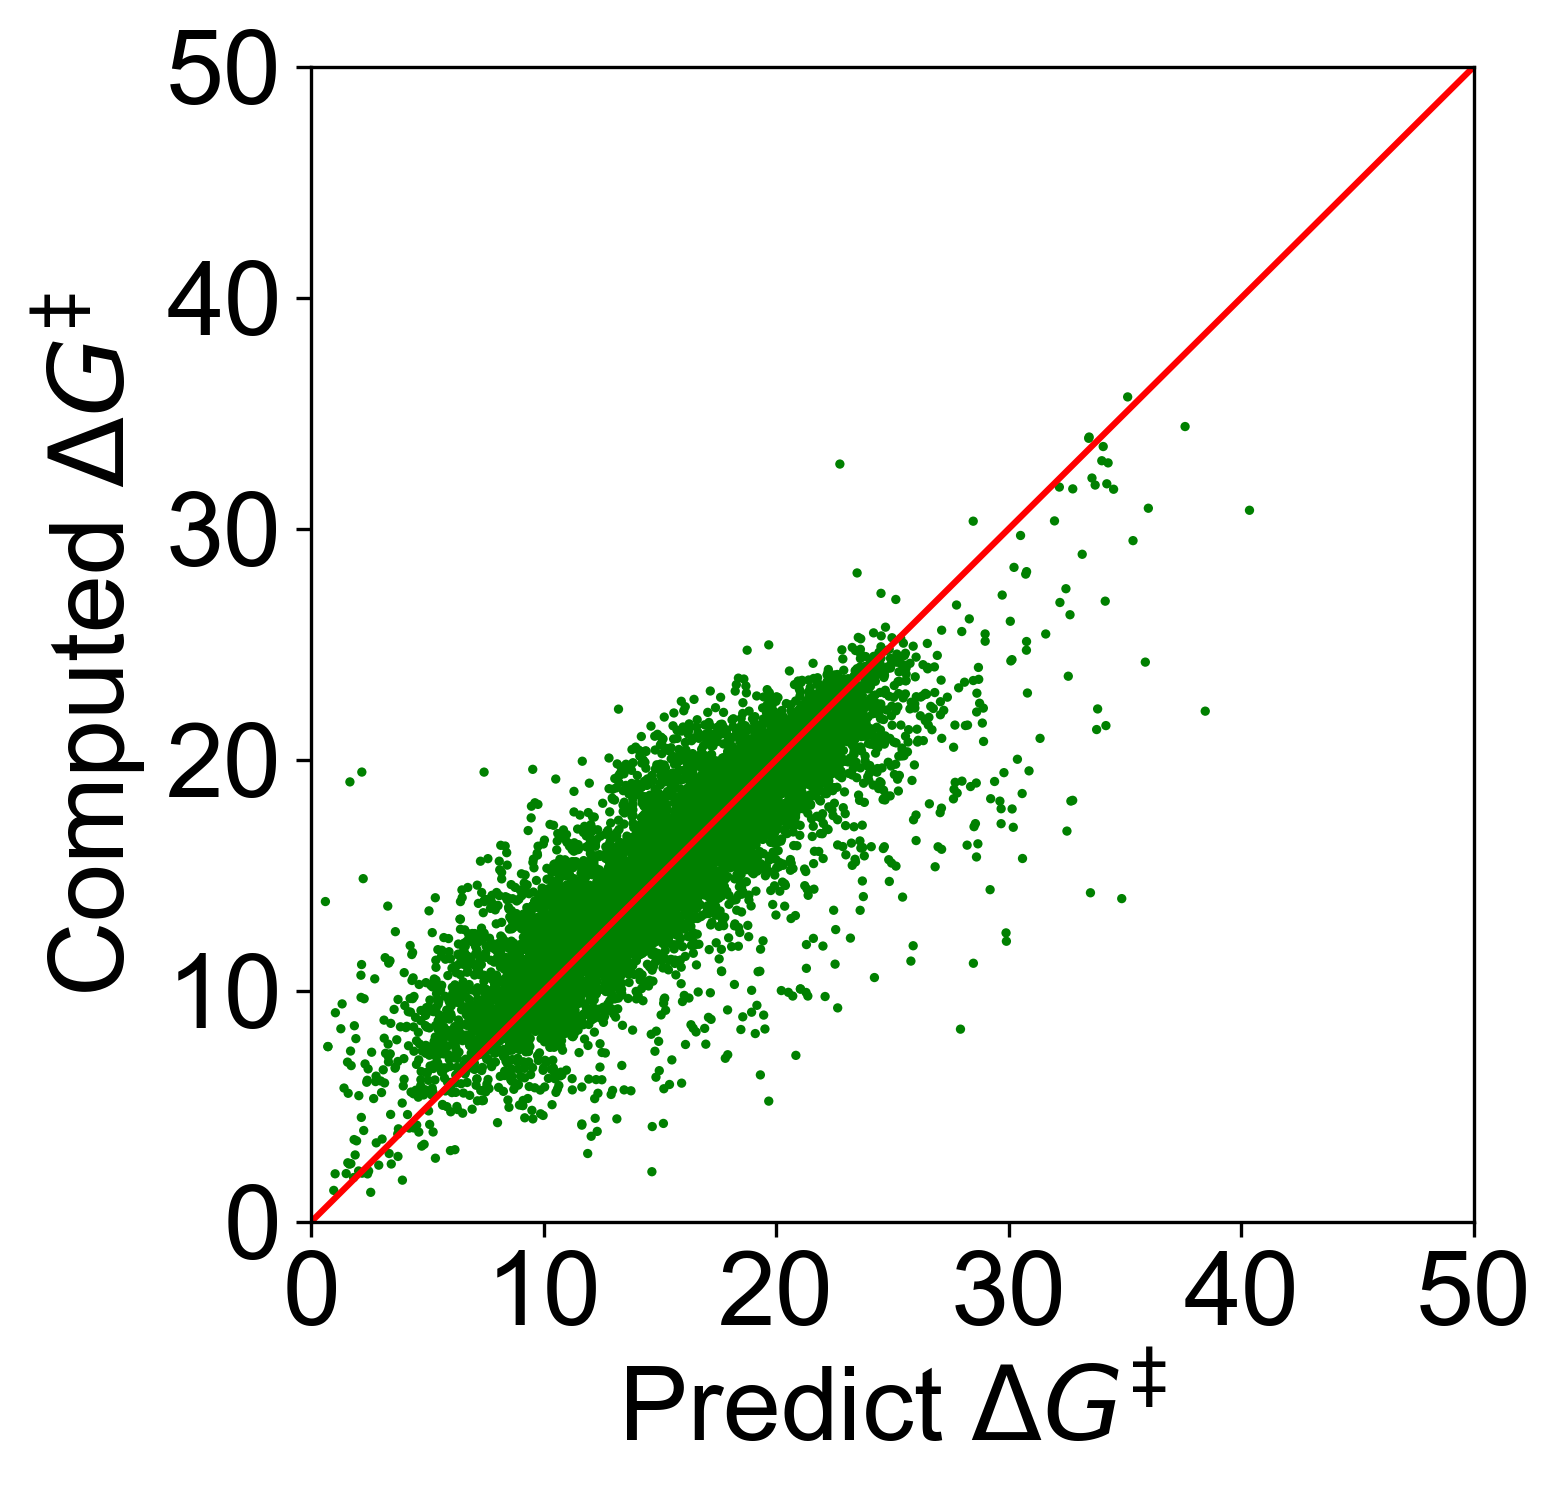

OOD by B_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,B_Index,1,44,11,7638,1342,0.780577,1.776323,5.831324
1,B_Index,2,44,11,7557,1423,0.790189,1.729720,5.581000
2,B_Index,3,44,11,6954,2026,0.806867,1.523602,4.406696
3,B_Index,4,44,11,7220,1760,0.793532,1.630649,4.993286
4,B_Index,5,44,11,6551,2429,0.826955,1.555526,4.555930


Mean fold R2: 0.7996239841832675 MAE: 1.6431640147558468
Overall R2: 0.803872074714118 MAE: 1.6236469155388


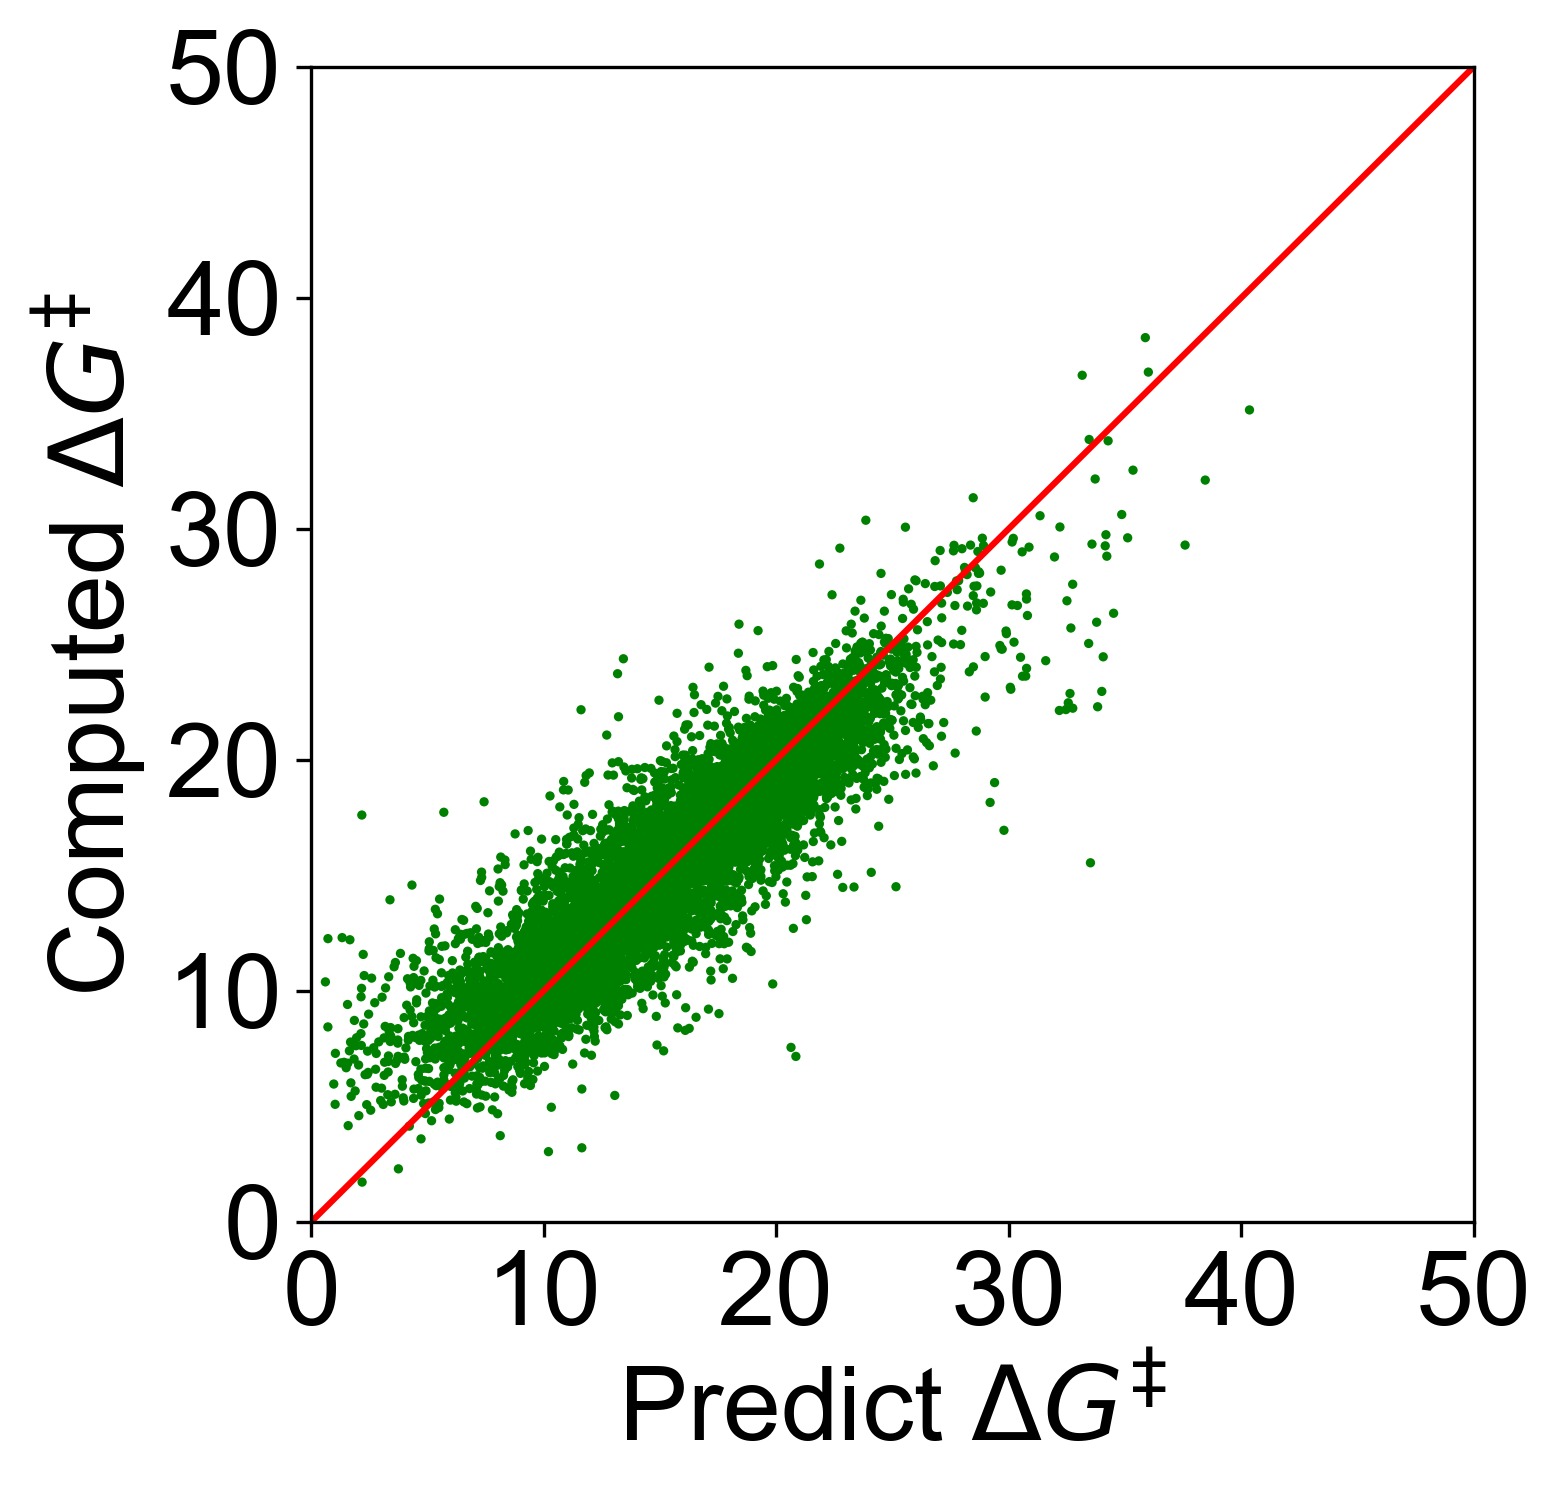

OOD by Nu_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Nu_Index,1,307,77,6598,2382,0.707824,1.822360,7.871415
1,Nu_Index,2,307,77,7303,1677,0.805943,1.566458,4.712439
2,Nu_Index,3,307,77,7455,1525,0.803089,1.518128,4.798447
3,Nu_Index,4,307,77,7302,1678,0.812151,1.660635,5.244299
4,Nu_Index,5,308,76,7262,1718,0.798836,1.499123,4.332720


Mean fold R2: 0.7855684158428513 MAE: 1.6133409127126785
Overall R2: 0.7789378082580969 MAE: 1.6308459256706551


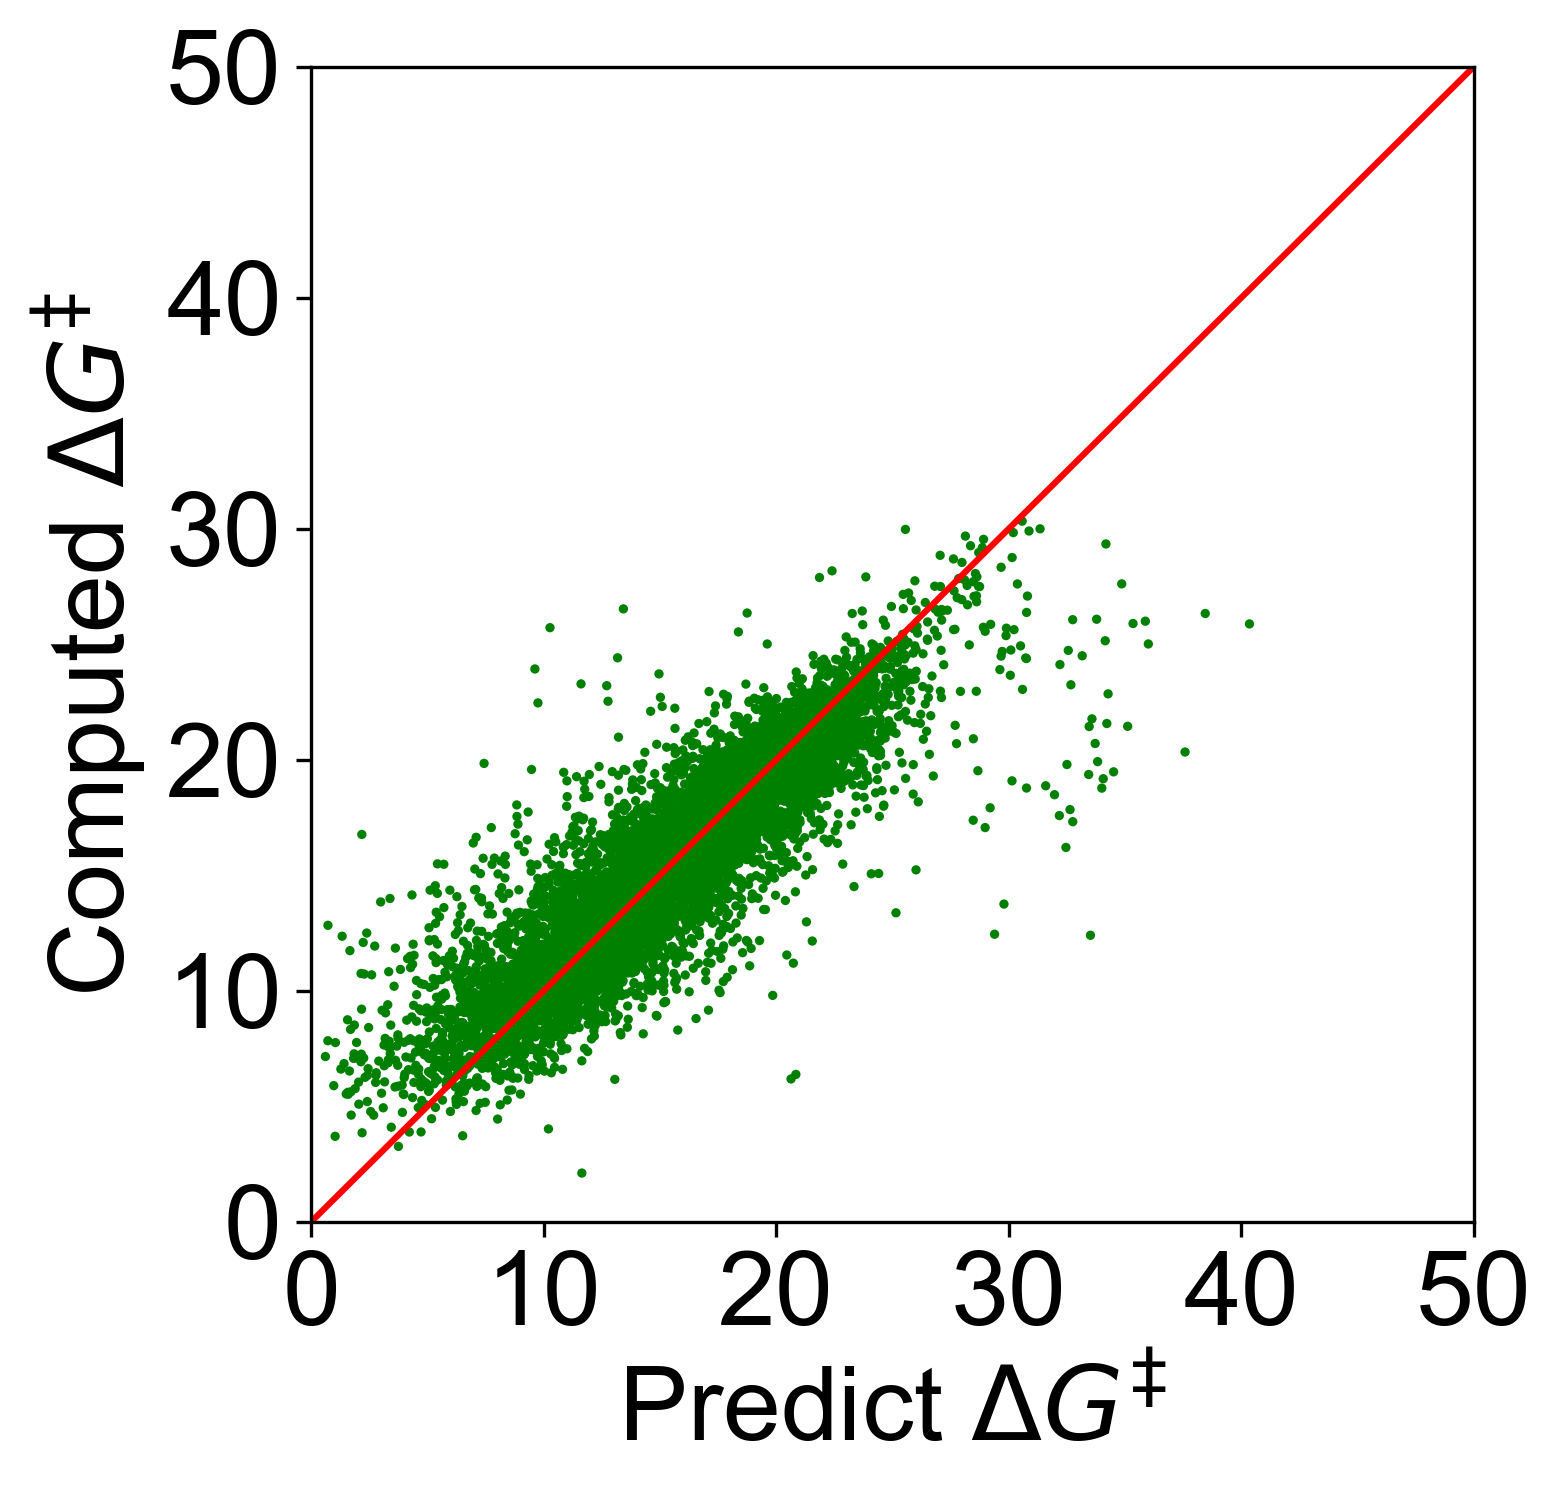

,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7058,1922,0.601151,2.385994,12.848330
1,Cl_Index,2,142,36,7296,1684,0.854915,1.398524,3.536901
2,Cl_Index,3,142,36,7348,1632,0.833984,1.449962,3.778592
3,Cl_Index,4,143,35,7200,1780,0.646649,2.072066,7.817774
4,Cl_Index,5,143,35,7018,1962,0.772813,1.585011,5.255390
5,B_Index,1,44,11,7638,1342,0.780577,1.776323,5.831324
6,B_Index,2,44,11,7557,1423,0.790189,1.729720,5.581000
7,B_Index,3,44,11,6954,2026,0.806867,1.523602,4.406696
8,B_Index,4,44,11,7220,1760,0.793532,1.630649,4.993286
9,B_Index,5,44,11,6551,2429,0.826955,1.555526,4.555930


In [ ]:
def run_index_ood(
    data_df,
    index_column,
    label=None,
    n_splits=5,
    target_column=BARRIER_COLUMN,
    min_test_size=2,
):
    label = label or index_column
    index_values = np.sort(data_df[index_column].dropna().unique())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

    result_rows = []
    pred_rows = []
    for fold_id, (train_ids, test_ids) in enumerate(kf.split(index_values), start=1):
        train_values = index_values[train_ids]
        test_values = index_values[test_ids]
        train_df = data_df.loc[data_df[index_column].isin(train_values)].reset_index(drop=True)
        test_df = data_df.loc[data_df[index_column].isin(test_values)].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": label,
            "fold": fold_id,
            "train_index_count": len(train_values),
            "test_index_count": len(test_values),
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": label,
                "fold": fold_id,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


ood_index_configs = {
    "Cl_Index": "Cl_Index",
    "B_Index": "B_Index",
    "N_Index": "Nu_Index",
}
ood_index_results = {}
ood_index_predictions = {}

for index_column, label in ood_index_configs.items():
    result_df, pred_df = run_index_ood(data_csv, index_column=index_column, label=label)
    ood_index_results[label] = result_df
    ood_index_predictions[label] = pred_df

    print(f"OOD by {label}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {label}")
        continue
    print(
        "Mean fold R2:",
        result_df["R2"].mean(),
        "MAE:",
        result_df["MAE"].mean(),
    )
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_index_results = [
    result_df for result_df in ood_index_results.values() if not result_df.empty
]
if nonempty_ood_index_results:
    ood_index_summary = pd.concat(nonempty_ood_index_results, ignore_index=True)
else:
    ood_index_summary = pd.DataFrame()
display(ood_index_summary)


## OOD around Types [REVIEWER-RUNNABLE]

Component-type held-out validation; no raw Gaussian folders are required.


B_type counts:
B_type
R2BH    2410
RBH2    5780
BH3      790

Nu_type counts:
Nu_type
Amine/Aryl N    5742
Phosphine       1798
NHC             1440

Cl_type counts:
Cl_type
CCl4     211
CCl3    1777
CCl2    2078
CCl     4914

OOD by B_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6570,2410,0.747675,1.943967,7.106343
1,B_type,RBH2,3200,5780,0.770842,1.727143,5.501330
2,B_type,BH3,8190,790,0.879290,1.266366,3.002982


Overall R2: 0.7741713696769726 MAE: 1.744797324950027


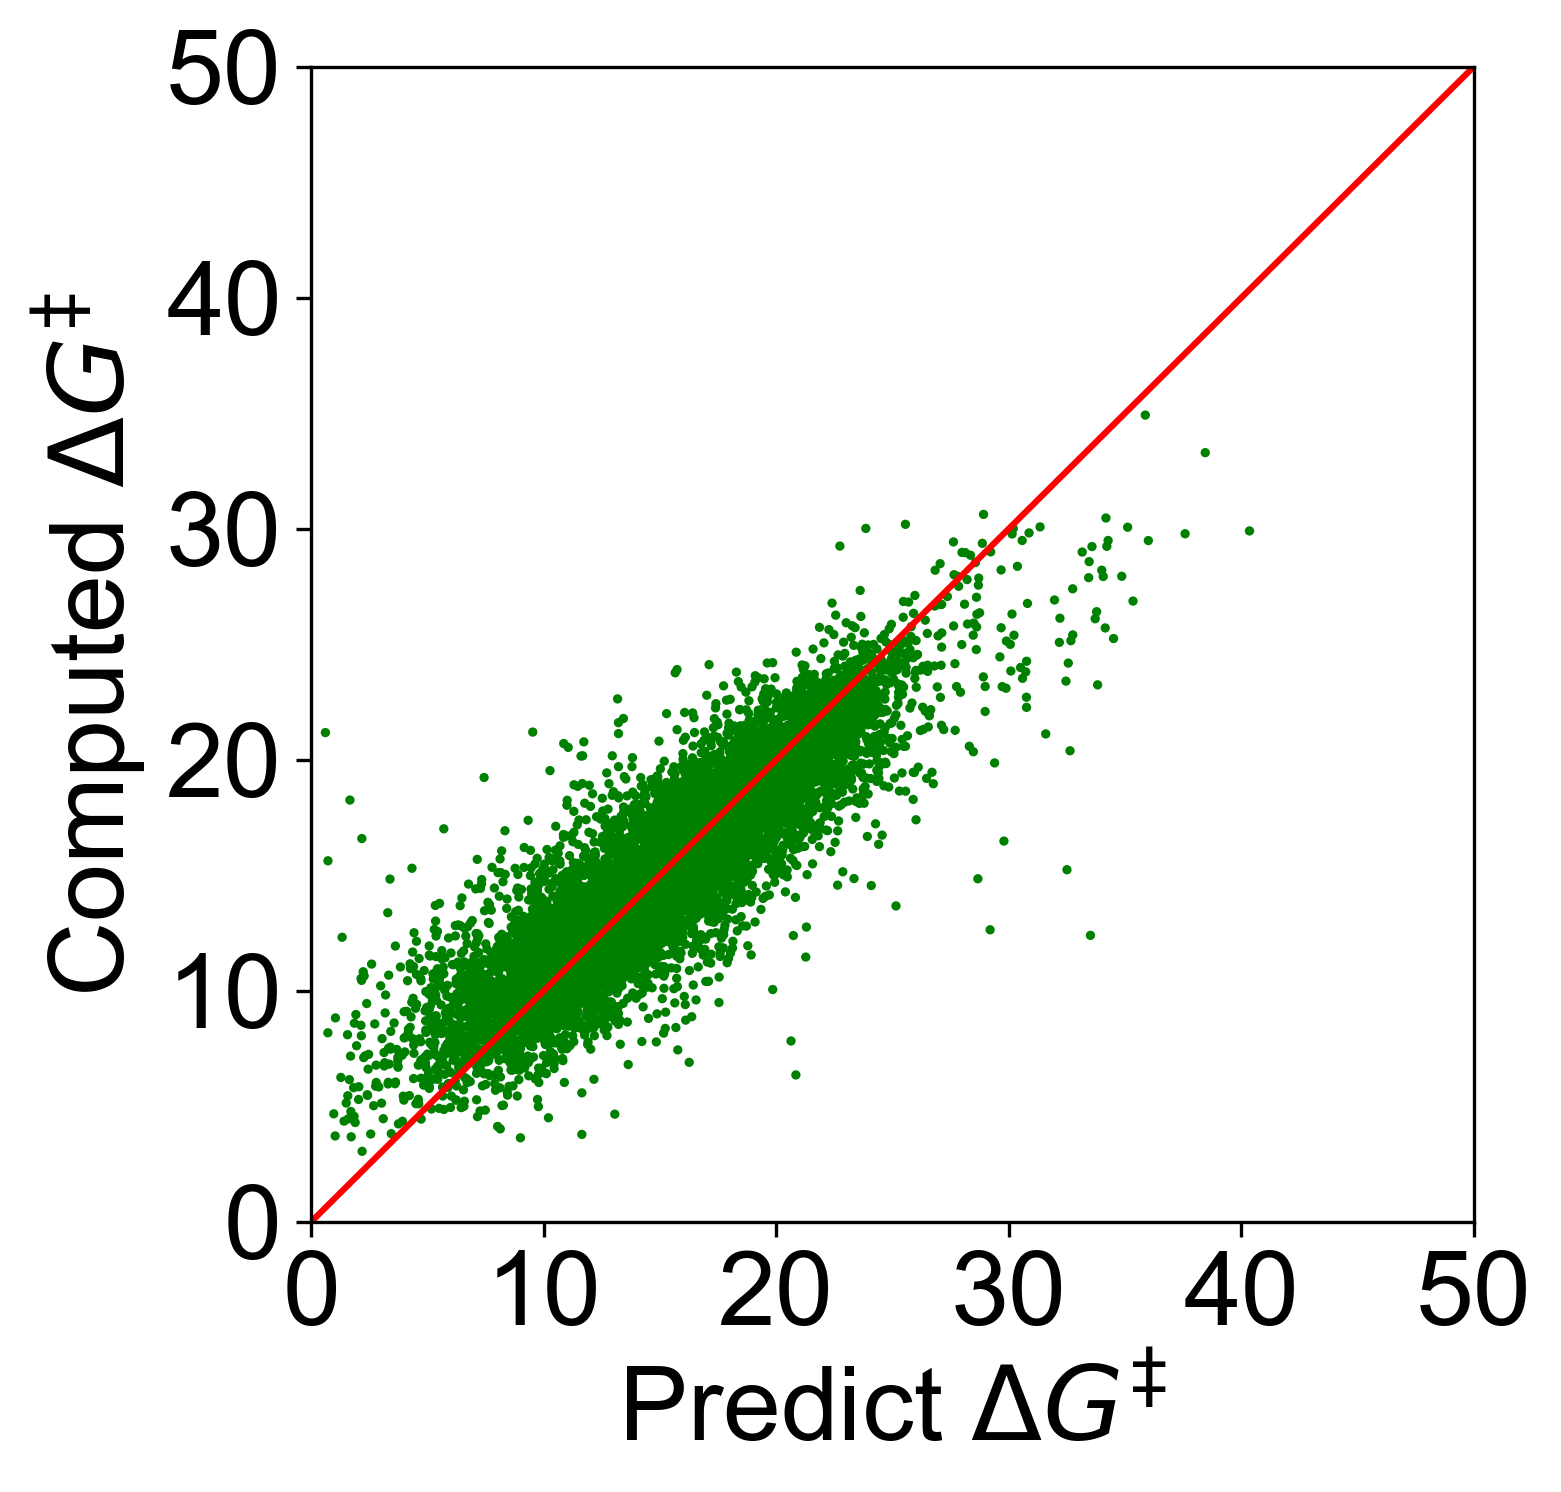

OOD by Nu_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Nu_type,Amine/Aryl N,3238,5742,0.667320,2.117065,8.830936
1,Nu_type,Phosphine,7182,1798,0.226524,2.871005,15.513834
2,Nu_type,NHC,7540,1440,0.657886,1.949535,7.372626


Overall R2: 0.6072251430756543 MAE: 2.2411566880423814


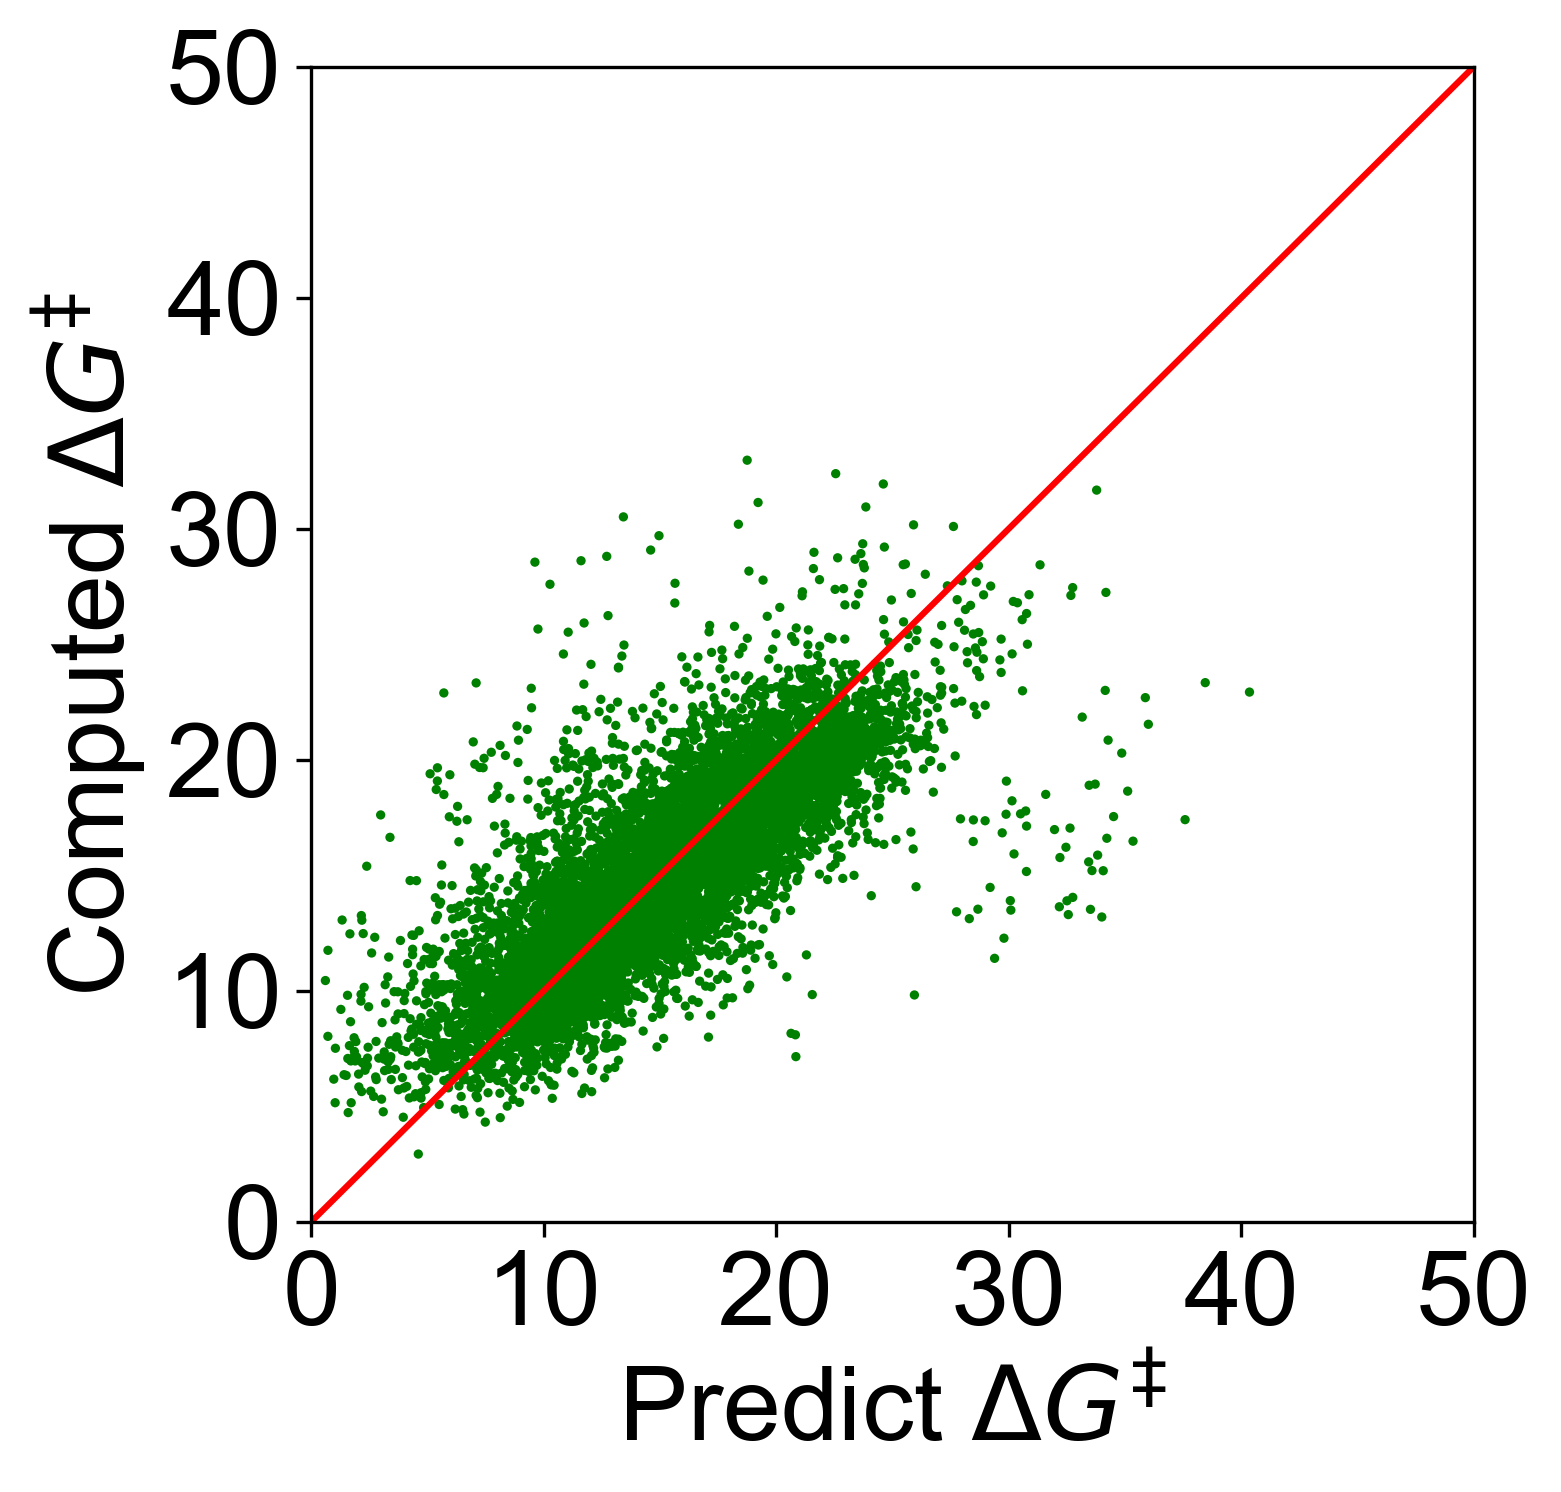

OOD by Cl_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Cl_type,CCl4,8769,211,0.899422,0.860257,1.609775
1,Cl_type,CCl3,7203,1777,0.826189,1.475795,3.865153
2,Cl_type,CCl2,6902,2078,0.843636,1.389388,3.541851
3,Cl_type,CCl,4066,4914,0.556707,2.516179,12.211715


Overall R2: 0.6716825606476233 MAE: 2.010651802077218


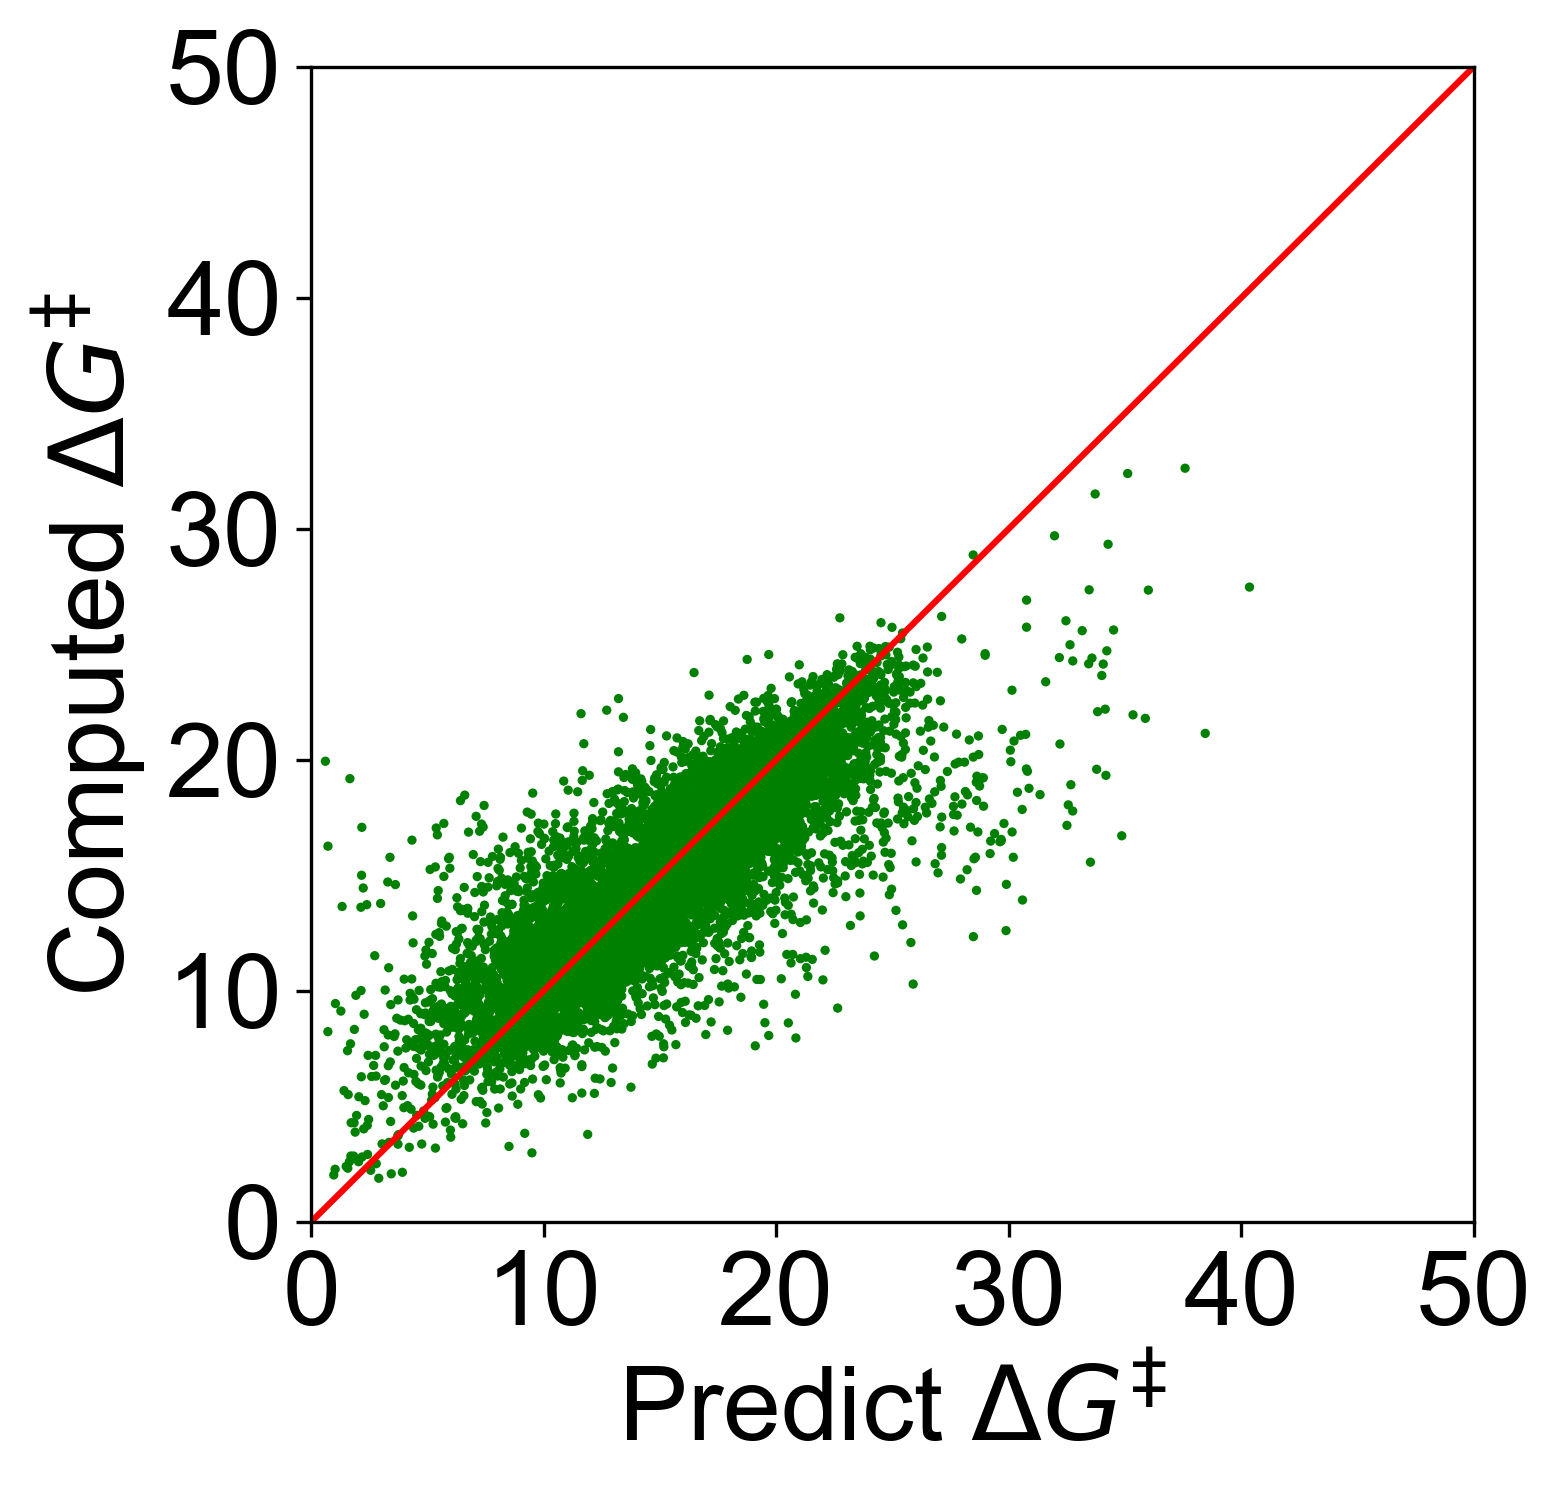

,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6570,2410,0.747675,1.943967,7.106343
1,B_type,RBH2,3200,5780,0.770842,1.727143,5.501330
2,B_type,BH3,8190,790,0.879290,1.266366,3.002982
3,Nu_type,Amine/Aryl N,3238,5742,0.667320,2.117065,8.830936
4,Nu_type,Phosphine,7182,1798,0.226524,2.871005,15.513834
5,Nu_type,NHC,7540,1440,0.657886,1.949535,7.372626
6,Cl_type,CCl4,8769,211,0.899422,0.860257,1.609775
7,Cl_type,CCl3,7203,1777,0.826189,1.475795,3.865153
8,Cl_type,CCl2,6902,2078,0.843636,1.389388,3.541851
9,Cl_type,CCl,4066,4914,0.556707,2.516179,12.211715


In [ ]:
def add_ood_type_columns(df):
    typed_df = df.copy()
    typed_df["B_type"] = typed_df["B_smiles"].map(get_boron_type)
    typed_df["Nu_type"] = typed_df["N_Index"].map(get_lb_type)
    typed_df["Cl_type"] = typed_df["Cl_smiles"].map(get_cl_substrate_type)
    return typed_df


def run_type_ood(
    typed_df,
    type_column,
    type_order=None,
    target_column=BARRIER_COLUMN,
    min_test_size=2,
):
    if type_order is None:
        type_order = sorted(typed_df[type_column].dropna().unique())

    result_rows = []
    pred_rows = []
    for heldout_type in type_order:
        test_df = typed_df.loc[typed_df[type_column] == heldout_type].reset_index(drop=True)
        train_df = typed_df.loc[typed_df[type_column] != heldout_type].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": type_column,
            "heldout_type": heldout_type,
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": type_column,
                "heldout_type": heldout_type,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


data_csv_typed = add_ood_type_columns(data_csv)
ood_type_counts = {
    "B_type": data_csv_typed["B_type"].value_counts().reindex(B_TYPE_ORDER).dropna().astype(int),
    "Nu_type": data_csv_typed["Nu_type"].value_counts().reindex(LB_TYPE_ORDER).dropna().astype(int),
    "Cl_type": data_csv_typed["Cl_type"].value_counts().reindex(CL_SUBSTRATE_TYPE_ORDER).dropna().astype(int),
}
for axis_name, counts in ood_type_counts.items():
    print(f"{axis_name} counts:")
    print(counts.to_string())
    print()


ood_type_results = {}
ood_type_predictions = {}
ood_type_configs = {
    "B_type": B_TYPE_ORDER,
    "Nu_type": LB_TYPE_ORDER,
    "Cl_type": CL_SUBSTRATE_TYPE_ORDER,
}

for type_column, type_order in ood_type_configs.items():
    result_df, pred_df = run_type_ood(
        data_csv_typed,
        type_column=type_column,
        type_order=type_order,
    )
    ood_type_results[type_column] = result_df
    ood_type_predictions[type_column] = pred_df

    print(f"OOD by {type_column}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {type_column}")
        continue
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_type_results = [
    result_df for result_df in ood_type_results.values() if not result_df.empty
]
if nonempty_ood_type_results:
    ood_type_summary = pd.concat(nonempty_ood_type_results, ignore_index=True)
else:
    ood_type_summary = pd.DataFrame()
display(ood_type_summary)
